## RCoxNet — step-by-step pipeline

This notebook walks through the full RCoxNet pipeline for one cancer type:
1. Load mutation + clinical data
2. Build PPI transition matrix
3. Compute RWR scores
4. Log-rank gene selection (top-K)
5. Train CoxPhRWRNet (20 repeats)
6. C-index results

Uses `best_params.json` (hyperparameters from the paper). Change `CANCER` below to run on a different cohort.

> **Prerequisites** — BRCA data is included. For LUNG/GBM/OV run `python download_data.py --cancer <NAME>` first.

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
%matplotlib inline

from rcoxnet.config import CANCER_CONFIGS, CLIN_FEATURES
from rcoxnet.data_loader import load_raw_data
from rcoxnet.mutations import parse_mutations
from rcoxnet.clinical import extract_clinical
from rcoxnet.network import build_transition_matrix
from rcoxnet.rwr import compute_rwr_scores
from rcoxnet.features import make_feature_df, select_top_k
from rcoxnet.model import CoxPhRWRNet, cox_loss, c_index
from rcoxnet.preprocessing import (
    censoring_time_balanced_split,
    normalise_genomic,
    normalise_clinical,
    prep,
)

CANCER = 'BRCA'   # change to LUNG / GBM / OV

ROOT   = os.getcwd()
cfg    = CANCER_CONFIGS[CANCER]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype  = torch.FloatTensor

with open(os.path.join(ROOT, 'best_params.json')) as f:
    params = json.load(f)[CANCER]

print(f'Cancer  : {CANCER}')
print(f'Device  : {device}')
print(f'Params  : {params}')

Cancer  : BRCA
Device  : cuda
Params  : {'alpha': 0.8, 'K': 600, 'hidden1': 64, 'hidden2': 16, 'output_nodes': 4, 'lr': 0.0001, 'l2': 0.01}


### Step 1 — Load data

In [2]:
mut_raw, clin_p_raw, clin_s_raw, ppi_path, _ = load_raw_data(ROOT, cfg)

print(f'Mutation file    : {mut_raw.shape}')
print(f'Clinical patient : {clin_p_raw.shape}')
print(f'Clinical sample  : {clin_s_raw.shape}')
print(f'PPI file         : {ppi_path}')

Data files:
  mut     : 141.0 MB  (/home/stutik/RCoxNet_GitHub/data/BRCA/data_mutations.txt)
  clin_p  : 0.3 MB  (/home/stutik/RCoxNet_GitHub/data/BRCA/data_clinical_patient.txt)
  clin_s  : 0.2 MB  (/home/stutik/RCoxNet_GitHub/data/BRCA/data_clinical_sample.txt)
  ppi     : 21.6 MB  (/home/stutik/RCoxNet_GitHub/data/BRCA/breast-PPI.txt)
Mutations : (130495, 111)  patients: 1009
Mutation file    : (130495, 111)
Clinical patient : (1084, 37)
Clinical sample  : (1084, 18)
PPI file         : /home/stutik/RCoxNet_GitHub/data/BRCA/breast-PPI.txt


In [3]:
# parse somatic mutations — keeps only nonsynonymous coding variants
seed_dict, mut_count_dict = parse_mutations(mut_raw)
print(f'Patients with mutations: {len(seed_dict)}')

Patients with functional mutations: 1009
Patients with mutations: 1009


In [4]:
# merge clinical + survival info, attach mutation seeds per patient
clinical, seed_by_patient, _ = extract_clinical(
    clin_p_raw, clin_s_raw, seed_dict, mut_count_dict, cfg)

print(f'Patients after QC : {len(clinical)}')
clinical[['SAMPLE_ID','OS_MONTHS','OS_STATUS','AGE','tmb_score','msi_score']].head()

Final cohort     : 1009 patients
Event rate       : 13.48%
Clinical features: ['AGE', 'msi_score', 'tmb_score']
Patients after QC : 1009


,SAMPLE_ID,OS_MONTHS,OS_STATUS,AGE,tmb_score,msi_score
0,TCGA-3C-AAAU-01,133.050597,0.0,55,0.800000,0.55
1,TCGA-3C-AALI-01,131.669790,0.0,50,15.266667,0.74
2,TCGA-3C-AALJ-01,48.459743,0.0,62,0.933333,0.31
3,TCGA-3C-AALK-01,47.604958,0.0,52,1.500000,0.03
4,TCGA-4H-AAAK-01,11.440971,0.0,50,0.700000,0.01


### Step 2 — PPI network

In [5]:
# build row-stochastic transition matrix from ConsensusPathDB PPI file
nodes, node_to_idx, W, _ = build_transition_matrix(ppi_path)
all_idx = np.arange(len(nodes))

print(f'PPI network genes : {len(nodes)}')
print(f'Transition matrix : {W.shape}  (row-stochastic: {np.allclose(W.sum(1), 1)})')

  Edges before filter: 522,578  →  after: 519,964  (IntConf>0, tpm≥0)
  Network genes: 18,172  |  Non-zero entries: 1,031,306
PPI network genes : 18172
Transition matrix : (18172, 18172)  (row-stochastic: False)


### Step 3 — Random Walk with Restart (RWR)

Each patient's somatic mutations define a seed vector. RWR propagates mutation signals across the PPI network.

$$\mathbf{p}^{(t+1)} = (1 - \alpha)\, W^\top \mathbf{p}^{(t)} + \alpha\, \mathbf{s}$$

α controls the restart probability (how strongly we pull back to the seed).

In [6]:
alpha = params['alpha']

rwr = compute_rwr_scores(
    clinical, W, nodes, node_to_idx,
    seed_by_patient, feat_idx=all_idx, alpha=alpha)

print(f'RWR matrix : {rwr.shape}  (patients × genes,  alpha={alpha})')

RWR matrix : (1009, 18172)  (patients × genes,  alpha=0.8)


In [7]:
# assemble feature dataframe — drops patients with no network signal
df = make_feature_df(rwr, nodes, clinical)

gene_arr = df[nodes].values.astype(np.float32)
clin_arr = df[CLIN_FEATURES].values.astype(np.float32)
yt       = df['OS_MONTHS'].values.astype(np.float32)
ye       = df['OS_STATUS'].values.astype(np.float32)

print(f'Final patients : {len(df)}')
print(f'Events         : {int(ye.sum())}  ({ye.mean()*100:.1f}%)')
print(f'Gene features  : {gene_arr.shape[1]}')
print(f'Clinical feats : {CLIN_FEATURES}')

Final patients : 1009
Events         : 136  (13.5%)
Gene features  : 18172
Clinical feats : ['AGE', 'msi_score', 'tmb_score']


### Step 4 — Log-rank gene selection

Top-K genes are selected by log-rank p-value (median split on each gene's RWR score). This keeps only genes whose network activity is prognostically informative.

In [8]:
K = params['K']

X_filt, selected_genes, pvals, sorted_idx = select_top_k(gene_arr, nodes, yt, ye, k=K)

print(f'Selected {X_filt.shape[1]} / {gene_arr.shape[1]} genes  (K={K})')
print(f'Top 10 genes: {selected_genes[:10]}')

Selected 600 / 18172 genes  (K=600)
Top 10 genes: ['AOC1', 'SPATS2L', 'ELAVL2', 'DHFR2', 'DPY19L4', 'ARL2BP', 'AXDND1', 'ANKRD46', 'PLEKHA3', 'LRRC25']


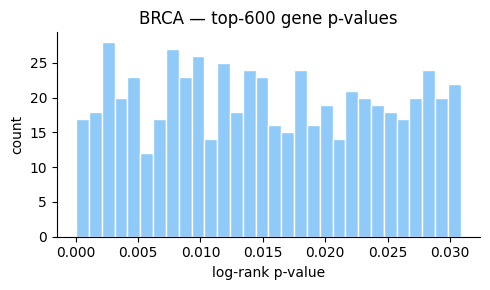

In [9]:
# quick look at p-value distribution of selected genes
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(pvals[sorted_idx[:K]], bins=30, color='#90CAF9', edgecolor='white')
ax.set_xlabel('log-rank p-value')
ax.set_ylabel('count')
ax.set_title(f'{CANCER} — top-{K} gene p-values')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Step 5 — Model definition

**CoxPhRWRNet** architecture:
```
RWR scores  →  Linear/Tanh  →  Linear/Tanh  →  Linear/Tanh  →  latent
                                                                    ↓
                                         concat [latent | AGE, TMB, MSI]  →  risk score
```

In [10]:
model_kwargs = dict(
    input_nodes  = X_filt.shape[1],
    hidden_nodes1= params['hidden1'],
    hidden_nodes2= params['hidden2'],
    output_nodes = params['output_nodes'],
    n_clin       = len(CLIN_FEATURES),
)

# print model structure for one example
net = CoxPhRWRNet(**model_kwargs)
print(net)
total = sum(p.numel() for p in net.parameters())
print(f'\nTotal parameters: {total:,}')

CoxPhRWRNet(
  (tanh): Tanh()
  (rwr_layer): Linear(in_features=600, out_features=64, bias=True)
  (hidden_layer1): Linear(in_features=64, out_features=16, bias=True)
  (hidden_layer2): Linear(in_features=16, out_features=4, bias=False)
  (cox_layer): Linear(in_features=7, out_features=1, bias=False)
)

Total parameters: 39,575


### Step 6 — Train and evaluate (20 repeats)

Each repeat uses a different random 70/10/20 stratified split. The best model checkpoint (highest validation C-index) is used to evaluate on the held-out test set.

In [11]:
import torch.optim as optim

N_REPEATS  = 20
EPOCHS     = 1000
CHECKPOINT = 50     # evaluate val C-index every N epochs
GRAD_CLIP  = 100
TEST_FRAC  = 0.20
VAL_FRAC   = 0.20

test_cis = []
val_cis  = []

for rep in range(N_REPEATS):
    rng = np.random.RandomState(rep * 7 + 13)
    tr, va, te = censoring_time_balanced_split(yt, ye, TEST_FRAC, VAL_FRAC, rng)

    Xg_tr, Xg_va, Xg_te = normalise_genomic(X_filt[tr], X_filt[va], X_filt[te])
    cl_tr, cl_va, cl_te  = normalise_clinical(clin_arr[tr], clin_arr[va], clin_arr[te])

    x_tr, cl_tr_t, yt_tr, ye_tr = prep(device, dtype, Xg_tr, cl_tr, yt[tr], ye[tr])
    x_va, cl_va_t, yt_va, ye_va = prep(device, dtype, Xg_va, cl_va, yt[va], ye[va])
    x_te, cl_te_t, yt_te, ye_te = prep(device, dtype, Xg_te, cl_te, yt[te], ye[te])

    torch.manual_seed(rep)
    np.random.seed(rep)
    net = CoxPhRWRNet(**model_kwargs).to(device)
    opt = optim.Adam(net.parameters(), lr=params['lr'], weight_decay=params['l2'])

    best_val, best_state = -1.0, None

    for epoch in range(EPOCHS):
        net.train()
        opt.zero_grad()
        loss = cox_loss(net(x_tr, cl_tr_t), yt_tr, ye_tr)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
        opt.step()

        if epoch % CHECKPOINT == 0:
            net.eval()
            with torch.no_grad():
                vc = c_index(net(x_va, cl_va_t), yt_va, ye_va).item()
            if vc > best_val:
                best_val  = vc
                best_state = {k: v.clone() for k, v in net.state_dict().items()}

    net.load_state_dict(best_state)
    net.eval()
    with torch.no_grad():
        tc = c_index(net(x_te, cl_te_t), yt_te, ye_te).item()

    test_cis.append(tc)
    val_cis.append(best_val)

    if (rep + 1) % 5 == 0:
        print(f'  rep {rep+1:2d}/20  test={tc:.3f}  val={best_val:.3f}  '
              f'running mean={np.mean(test_cis):.3f}')

print(f'\n{CANCER}  test C-index: {np.mean(test_cis):.3f} ± {np.std(test_cis):.3f}')
print(f'{CANCER}  val  C-index: {np.mean(val_cis):.3f} ± {np.std(val_cis):.3f}')

  rep  5/20  test=0.762  val=0.870  running mean=0.811
  rep 10/20  test=0.747  val=0.749  running mean=0.807
  rep 15/20  test=0.727  val=0.870  running mean=0.802
  rep 20/20  test=0.857  val=0.779  running mean=0.801

BRCA  test C-index: 0.801 ± 0.044
BRCA  val  C-index: 0.800 ± 0.047


### Step 7 — C-index results

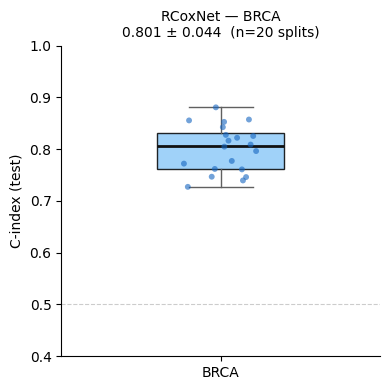

In [12]:
fig, ax = plt.subplots(figsize=(4, 4))

ax.boxplot(test_cis, widths=0.4, patch_artist=True,
           boxprops=dict(facecolor='#90CAF9', alpha=0.85),
           medianprops=dict(color='#111111', linewidth=2),
           whiskerprops=dict(color='#606060'),
           capprops=dict(color='#606060'),
           flierprops=dict(marker='o', markersize=4, markerfacecolor='#aaaaaa',
                           markeredgewidth=0, alpha=0.7))

# jitter
np.random.seed(0)
jx = np.random.uniform(-0.12, 0.12, len(test_cis))
ax.scatter(1 + jx, test_cis, color='#1565C0', s=18, alpha=0.6, zorder=3, edgecolors='none')

ax.axhline(0.5, color='#cccccc', lw=0.8, linestyle='--')
ax.set_xticks([1])
ax.set_xticklabels([CANCER])
ax.set_ylabel('C-index (test)')
ax.set_ylim(0.4, 1.0)
ax.set_title(f'RCoxNet — {CANCER}\n'
             f'{np.mean(test_cis):.3f} ± {np.std(test_cis):.3f}  (n=20 splits)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

### Optional — run the full pipeline via `run_pipeline()`

The cells above manually step through each component. The same result can be obtained in one call:

In [14]:
# full joint grid search (α × K × arch × LR × L2) — takes several hours
# uncomment to run:
# from rcoxnet.pipeline import run_pipeline
# result = run_pipeline(CANCER, root=ROOT)
# print(result['test_ci_mean'], result['test_ci_std'])